# Model Evaluation and Explainability

A model with good accuracy means nothing if we can't explain it. In credit risk, banks are legally required to explain why a loan was rejected. This notebook dives deep into evaluation metrics and uses SHAP to explain individual predictions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load model and data
model = joblib.load('../models/model.pkl')
scaler = joblib.load('../models/scaler.pkl')
X_train, X_test, y_train, y_test = joblib.load('../data/processed/train_test_split.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

print("Everything loaded successfully!")

Everything loaded successfully!


## Step 1: Why ROC-AUC is Not Enough

Accuracy is a misleading metric for imbalanced datasets. If 93% of people don't default, a model predicting "no default" for everyone gets 93% accuracy but catches zero defaulters.

In credit risk, I care about:
- Precision: of all predicted defaults, how many actually defaulted?
- Recall: of all actual defaults, how many did I catch?
- The business cost of each type of error

In [2]:
# Get predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

# Full evaluation
print("=" * 55)
print("MODEL EVALUATION REPORT")
print("=" * 55)
print(f"\nROC-AUC Score:        {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Average Precision:    {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report (threshold = 0.5):\n")
print(classification_report(y_test, y_pred, 
                             target_names=['No Default', 'Default']))

MODEL EVALUATION REPORT

ROC-AUC Score:        0.8332
Average Precision:    0.2990

Classification Report (threshold = 0.5):

              precision    recall  f1-score   support

  No Default       0.96      0.89      0.93     27995
     Default       0.26      0.55      0.35      2005

    accuracy                           0.87     30000
   macro avg       0.61      0.72      0.64     30000
weighted avg       0.92      0.87      0.89     30000



## Step 2: Confusion Matrix

The confusion matrix shows exactly where the model makes mistakes. In business terms:
- False Negative = we predicted "no default" but they defaulted (bank loses money)
- False Positive = we predicted "default" but they didn't (bank loses a good customer)

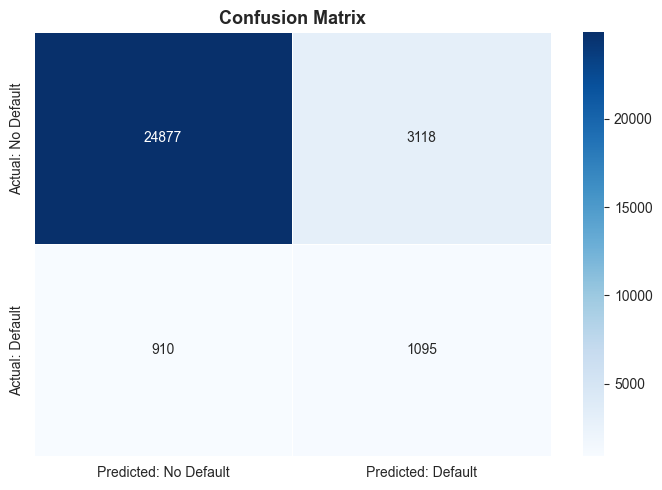


True Negatives  (correct no-default):  24,877
False Positives (rejected good customer): 3,118
False Negatives (missed defaulter):     910
True Positives  (caught defaulter):     1,095

Business insight: We missed 910 actual defaulters.
Each missed default costs the bank the full loan amount.


In [3]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Default', 'Predicted: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'],
            linewidths=0.5)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrue Negatives  (correct no-default):  {tn:,}")
print(f"False Positives (rejected good customer): {fp:,}")
print(f"False Negatives (missed defaulter):     {fn:,}")
print(f"True Positives  (caught defaulter):     {tp:,}")
print(f"\nBusiness insight: We missed {fn:,} actual defaulters.")
print(f"Each missed default costs the bank the full loan amount.")

## Step 3: Threshold Tuning

The default threshold of 0.5 is rarely optimal for imbalanced problems. By adjusting the threshold, I can trade off between catching more defaulters (higher recall) vs rejecting fewer good customers (higher precision).

This is a business decision, not a pure ML decision.

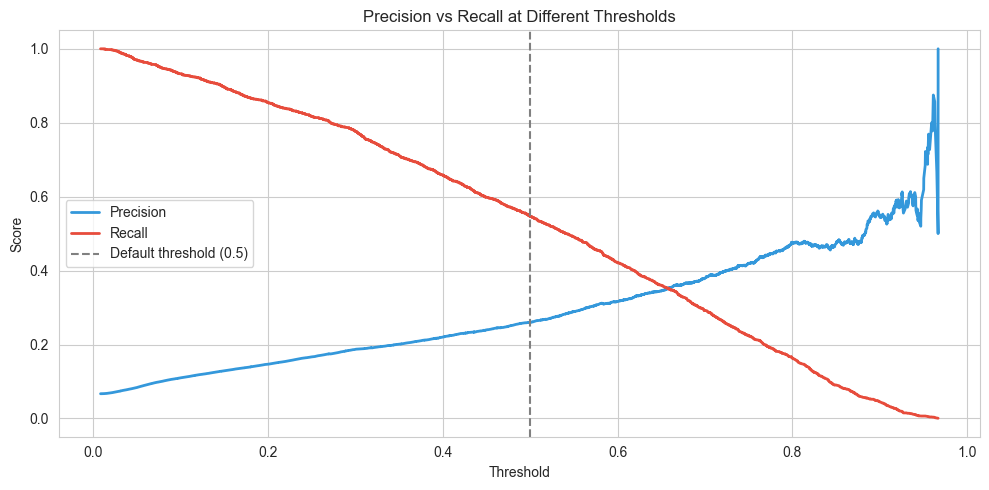

In [4]:
# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='#3498db', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', color='#e74c3c', linewidth=2)
plt.axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('../data/precision_recall_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Find optimal threshold using F1 score
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold (max F1): {optimal_threshold:.4f}")
print(f"Precision at optimal:       {precision[optimal_idx]:.4f}")
print(f"Recall at optimal:          {recall[optimal_idx]:.4f}")
print(f"F1 at optimal:              {f1_scores[optimal_idx]:.4f}")

# Save optimal threshold for deployment
joblib.dump(optimal_threshold, '../models/threshold.pkl')
print(f"\nOptimal threshold saved to ../models/threshold.pkl")

Optimal threshold (max F1): 0.5801
Precision at optimal:       0.3110
Recall at optimal:          0.4534
F1 at optimal:              0.3689

Optimal threshold saved to ../models/threshold.pkl


In [6]:
# Compare default threshold vs optimal threshold
y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print("At threshold = 0.5:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

print(f"At threshold = {optimal_threshold:.4f} (optimal):")
print(classification_report(y_test, y_pred_optimal, target_names=['No Default', 'Default']))

At threshold = 0.5:
              precision    recall  f1-score   support

  No Default       0.96      0.89      0.93     27995
     Default       0.26      0.55      0.35      2005

    accuracy                           0.87     30000
   macro avg       0.61      0.72      0.64     30000
weighted avg       0.92      0.87      0.89     30000

At threshold = 0.5801 (optimal):
              precision    recall  f1-score   support

  No Default       0.96      0.93      0.94     27995
     Default       0.31      0.45      0.37      2005

    accuracy                           0.90     30000
   macro avg       0.64      0.69      0.66     30000
weighted avg       0.92      0.90      0.91     30000



## Step 4: Feature Importance

Which features does the model rely on most? This is important for both model trust and regulatory compliance.

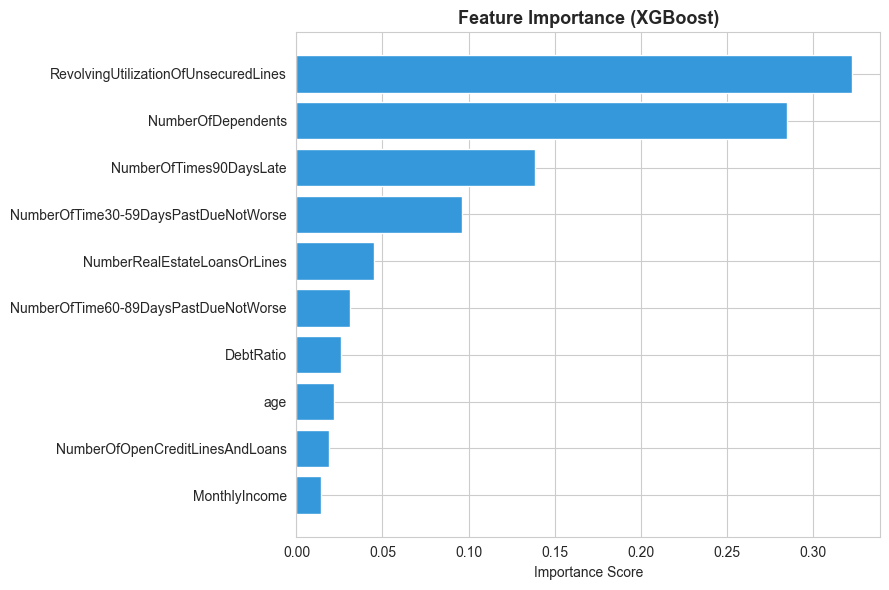

In [7]:
# XGBoost built-in feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='#3498db', edgecolor='white')
plt.title('Feature Importance (XGBoost)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: SHAP Explainability

Feature importance tells us which features matter globally. SHAP (SHapley Additive exPlanations) goes further, it explains why the model made a specific prediction for a specific applicant.

This is critical for credit risk because regulators require lenders to explain individual decisions.

In [8]:
# SHAP values using newer API
print("Calculating SHAP values...")

explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test, check_additivity=False)

print("SHAP values calculated!")
print(f"Shape of SHAP values: {shap_values.values.shape}")

Calculating SHAP values...


100%|===================| 29913/30000 [04:45<00:00]        

SHAP values calculated!
Shape of SHAP values: (30000, 10)


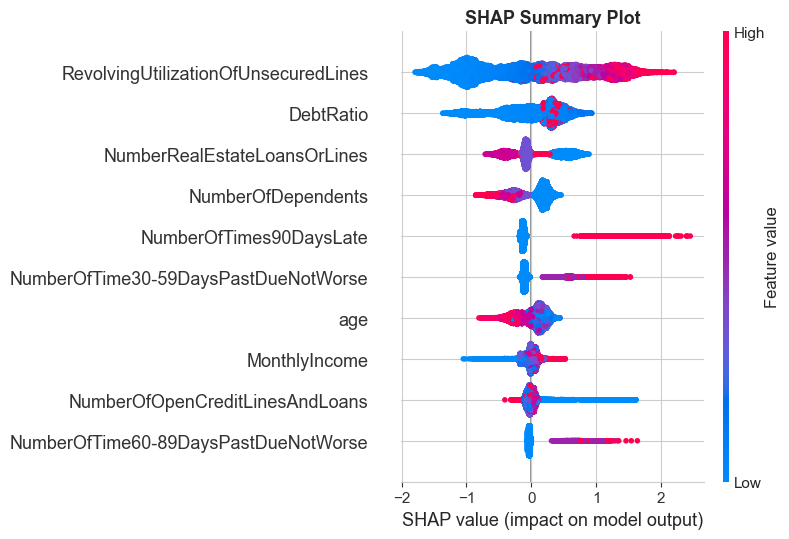

In [9]:
# SHAP summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test,
                  feature_names=feature_names,
                  show=False)
plt.title('SHAP Summary Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

Applicant #10 details:
                                            Value
RevolvingUtilizationOfUnsecuredLines     0.096229
age                                     50.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.513236
MonthlyIncome                         5363.000000
NumberOfOpenCreditLinesAndLoans          6.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             2.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       3.000000

Predicted default probability: 0.0607
Prediction: LOW RISK


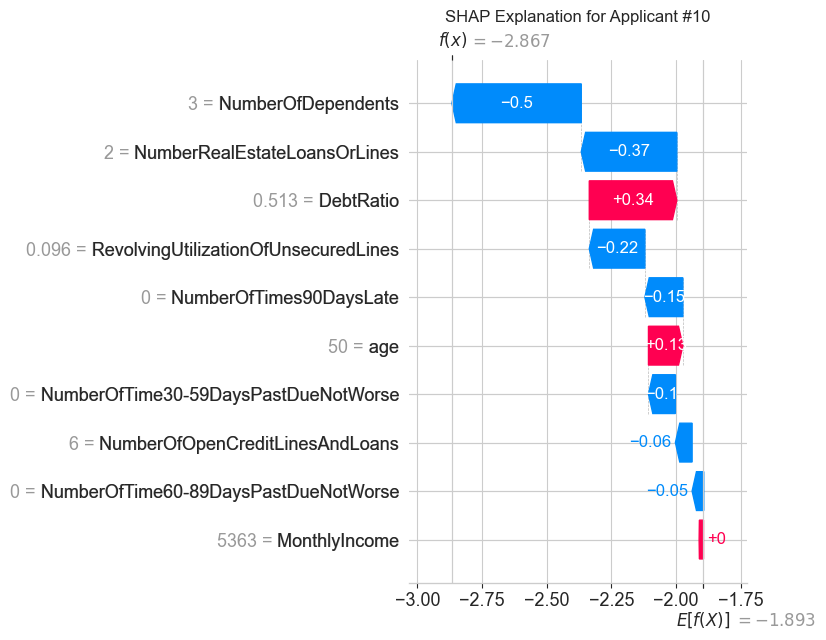

In [10]:
# SHAP for a single applicant
sample_idx = 10
sample = X_test.iloc[[sample_idx]]
sample_pred = model.predict_proba(sample)[0][1]

print(f"Applicant #{sample_idx} details:")
print(sample.T.rename(columns={sample.index[0]: 'Value'}))
print(f"\nPredicted default probability: {sample_pred:.4f}")
print(f"Prediction: {'DEFAULT RISK' if sample_pred >= optimal_threshold else 'LOW RISK'}")

# Waterfall plot
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[sample_idx], show=False)
plt.title(f'SHAP Explanation for Applicant #{sample_idx}', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Save SHAP explainer
joblib.dump(explainer, '../models/shap_explainer.pkl')
print("SHAP explainer saved to ../models/shap_explainer.pkl")

SHAP explainer saved to ../models/shap_explainer.pkl


## Summary

- Evaluated model using ROC-AUC, precision, recall and confusion matrix
- Explained the business cost of false negatives vs false positives
- Tuned the classification threshold for optimal F1 score
- Used SHAP to explain both global feature importance and individual predictions
- All artifacts saved for deployment: model.pkl, scaler.pkl, threshold.pkl, shap_explainer.pkl

Next: Building the Streamlit app and deploying it live.